This file contains model evaluation similar to the 04 file, but condensed in a nicer way for easier comparisons.

# Entry inclusion task
## Running missing tests
The teset I already have - bert 2/3 svm 1/3 Gemini 1/3
### BERT

In [1]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 3070


In [3]:
import torch
import pandas as pd
from transformers import BertTokenizer, BertForSequenceClassification
from tqdm import tqdm

# Load model
model_path = "Models/bert_250k_title_abstract"
tokenizer = BertTokenizer.from_pretrained(model_path)
model = BertForSequenceClassification.from_pretrained(model_path)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

# Load data
df = pd.read_csv("Datasets/Inclusion_Classification/Test/400k_test.csv")
df["text"] = df["title"].fillna("") + " " + df["abstract"].fillna("")
texts = df["text"].tolist()
row_ids = df["row_id"].tolist()

# Predict
batch_size = 8
pred_labels, pred_probs = [], []

for i in tqdm(range(0, len(texts), batch_size), desc="BERT on 400k mixed"):
    batch_texts = texts[i:i+batch_size]
    inputs = tokenizer(batch_texts, padding=True, truncation=True, max_length=512, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=1)
    pred_labels.extend(torch.argmax(probs, dim=1).tolist())
    pred_probs.extend(probs[:, 1].tolist())

# Save
df_out = pd.DataFrame({"row_id": row_ids, "pred_label": pred_labels, "prob_1": pred_probs})
df_out.to_csv("Model_Predictions/bert_250k_on_400k_mixed.csv", index=False)
print("✅ BERT predictions saved to Model_Predictions/bert_250k_on_400k_mixed.csv")


BERT on 400k mixed: 100%|██████████| 11054/11054 [18:23<00:00, 10.02it/s]


✅ BERT predictions saved to Model_Predictions/bert_250k_on_400k_mixed.csv


### SVMs

In [5]:
import joblib
import pandas as pd

# Load model and vectorizer
vectorizer, model = joblib.load("Models/svm_250k_title_abstract.joblib")

def run_svm_prediction(input_path, output_path, use_abstract=True):
    df = pd.read_csv(input_path)
    if use_abstract:
        df["text"] = df["title"].fillna("") + " " + df["abstract"].fillna("")
    else:
        df["text"] = df["title"].fillna("")
    X = vectorizer.transform(df["text"])
    probs = model.predict_proba(X)[:, 1]
    preds = (probs >= 0.5).astype(int)
    df_out = pd.DataFrame({"row_id": df["row_id"], "svm_pred_label": preds, "svm_pred_prob": probs})
    df_out.to_csv(output_path, index=False)
    print(f"✅ SVM predictions saved to {output_path}")

# ──────────────── Run Predictions ────────────────

# 1. For 400k mixed (title + abstract)
run_svm_prediction(
    input_path="Datasets/Inclusion_Classification/Test/400k_test.csv",
    output_path="Model_Predictions/svm_250k_on_400k_mixed_preds.csv"
)

# 2. For 400k title-only
run_svm_prediction(
    input_path="Datasets/Inclusion_Classification/Test/400k_test.csv",
    output_path="Model_Predictions/svm_250k_on_400k_titles_only_preds.csv",
    use_abstract=False
)


✅ SVM predictions saved to Model_Predictions/svm_250k_on_400k_mixed_preds.csv
✅ SVM predictions saved to Model_Predictions/svm_250k_on_400k_titles_only_preds.csv


### Gemini

In [6]:
import pandas as pd
from google import genai
from tqdm import tqdm
import os

# ─── Gemini Client ─────────────────────────────
client = genai.Client(api_key=os.getenv("GEMINI_API_KEY"))
model_name = "gemini-2.0-flash"

# ─── Prompt Builder ─────────────────────────────
def build_prompt(text):
    return (
        "You are an expert in tropical diseases. "
        "Given the following medical research paper's title and abstract, answer only with 'Yes' or 'No':\n\n"
        f"{text}\n\n"
        "Is this paper about neglected tropical diseases?"
    )

# ─── Cost Estimation Function ──────────────────
def estimate_cost(prompt_tokens, response_tokens):
    return round((prompt_tokens * 0.00025 + response_tokens * 0.00050) / 1000, 6)

# ─── Prediction Function ───────────────────────
def run_gemini(input_path, output_path, use_abstract=True):
    df = pd.read_csv(input_path)
    df["text"] = df["title"].fillna("") + (" " + df["abstract"].fillna("") if use_abstract else "")
    results = []

    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"Gemini on {output_path}"):
        try:
            prompt = build_prompt(row["text"])
            response = client.models.generate_content(model=model_name, contents=prompt)

            answer = response.text.strip()
            label = 1 if "yes" in answer.lower() else 0

            usage = response.usage_metadata
            prompt_tokens = usage.prompt_token_count or 0
            response_tokens = usage.candidates_token_count or 0
            total_tokens = usage.total_token_count or 0
            cost = estimate_cost(prompt_tokens, response_tokens)

        except Exception as e:
            answer = str(e)
            label = -1
            prompt_tokens = response_tokens = total_tokens = 0
            cost = 0.0

        results.append({
            "row_id": row["row_id"],
            "gemini_pred": label,
            "gemini_response": answer,
            "prompt_tokens": prompt_tokens,
            "response_tokens": response_tokens,
            "total_tokens": total_tokens,
            "estimated_cost_usd": cost
        })

    df_out = pd.DataFrame(results)
    df_out.to_csv(output_path, index=False)
    print(f"✅ Gemini predictions saved to {output_path}")
    print(f"💰 Total estimated cost: ${df_out['estimated_cost_usd'].sum():.4f}")

# ─── Run Predictions ───────────────────────────

# 1. With abstracts
run_gemini(
    input_path="Datasets/Inclusion_Classification/Test/400k_test.csv",
    output_path="Model_Predictions/gemini_2-0_flash_400k_mixed_preds.csv"
)

# 2. Title-only
run_gemini(
    input_path="Datasets/Inclusion_Classification/Test/400k_test.csv",
    output_path="Model_Predictions/gemini_2-0_flash_400k_titles_only_preds.csv",
    use_abstract=False
)


Gemini on Model_Predictions/gemini_2-0_flash_400k_mixed_preds.csv:   0%|          | 179/88425 [01:04<8:47:07,  2.79it/s] 


KeyboardInterrupt: 

In [2]:
import pandas as pd
import os
from google import genai
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed
import random

# ─── Gemini Client ─────────────────────────────
client = genai.Client(api_key=os.getenv("GEMINI_API_KEY"))
model_name = "gemini-2.0-flash"

# ─── Prompt Builder ─────────────────────────────
def build_prompt(text):
    return (
        "You are an expert in tropical diseases. "
        "Given the following medical research paper's title and abstract, answer only with 'Yes' or 'No':\n\n"
        f"{text}\n\n"
        "Is this paper about neglected tropical diseases?"
    )

# ─── Cost Estimation Function ──────────────────
def estimate_cost(prompt_tokens, response_tokens):
    return round((prompt_tokens * 0.00025 + response_tokens * 0.00050) / 1000, 6)

# ─── Worker Function ────────────────────────────
def predict_row(row):
    try:
        prompt = build_prompt(row["text"])
        response = client.models.generate_content(model=model_name, contents=prompt)

        answer = response.text.strip()
        label = 1 if "yes" in answer.lower() else 0

        usage = response.usage_metadata
        prompt_tokens = usage.prompt_token_count or 0
        response_tokens = usage.candidates_token_count or 0
        total_tokens = usage.total_token_count or 0
        cost = estimate_cost(prompt_tokens, response_tokens)

    except Exception as e:
        answer = str(e)
        label = -1
        prompt_tokens = response_tokens = total_tokens = 0
        cost = 0.0

    return {
        "row_id": row["row_id"],
        "gemini_pred": label,
        "gemini_response": answer,
        "prompt_tokens": prompt_tokens,
        "response_tokens": response_tokens,
        "total_tokens": total_tokens,
        "estimated_cost_usd": cost
    }

# ─── Prediction Function ───────────────────────
def run_gemini_sampled(input_path, output_path, use_abstract=True, sample_frac=1/3, max_workers=2):
    df = pd.read_csv(input_path)
    df_sampled = df.sample(frac=sample_frac, random_state=42).reset_index(drop=True)

    if use_abstract:
        df_sampled["text"] = df_sampled["title"].fillna("") + " " + df_sampled["abstract"].fillna("")
    else:
        df_sampled["text"] = df_sampled["title"].fillna("")

    results = []
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [executor.submit(predict_row, row) for _, row in df_sampled.iterrows()]
        for future in tqdm(as_completed(futures), total=len(futures), desc="Running Gemini"):
            results.append(future.result())

    df_out = pd.DataFrame(results)
    df_out.to_csv(output_path, index=False)
    print(f"✅ Gemini predictions saved to {output_path}")
    print(f"💰 Total estimated cost: ${df_out['estimated_cost_usd'].sum():.4f}")

# ─── Run Predictions ───────────────────────────

# 1. With abstracts
run_gemini_sampled(
    input_path="Datasets/Inclusion_Classification/Test/400k_test.csv",
    output_path="Model_Predictions/gemini_2-0_flash_400k_mixed_preds_SAMPLE.csv",
    use_abstract=True
)

# 2. Title-only
run_gemini_sampled(
    input_path="Datasets/Inclusion_Classification/Test/400k_test.csv",
    output_path="Model_Predictions/gemini_2-0_flash_400k_titles_only_preds_SAMPLE.csv",
    use_abstract=False
)


Running Gemini: 100%|██████████| 29475/29475 [1:25:40<00:00,  5.73it/s] 


✅ Gemini predictions saved to Model_Predictions/gemini_2-0_flash_400k_mixed_preds_SAMPLE.csv
💰 Total estimated cost: $1.6044


Running Gemini: 100%|██████████| 29475/29475 [1:27:12<00:00,  5.63it/s]


✅ Gemini predictions saved to Model_Predictions/gemini_2-0_flash_400k_titles_only_preds_SAMPLE.csv
💰 Total estimated cost: $0.4658


In [3]:
import pandas as pd
import os
from google import genai
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed
import random

# ─── Gemini Client ─────────────────────────────
client = genai.Client(api_key=os.getenv("GEMINI_API_KEY"))
model_name = "gemini-2.0-flash"

# ─── Prompt Builder ─────────────────────────────
def build_prompt(text):
    return (
        "You are an expert in tropical diseases. "
        "Given the following medical research paper's title and abstract, answer only with 'Yes' or 'No':\n\n"
        f"{text}\n\n"
        "Is this paper about neglected tropical diseases?"
    )

# ─── Cost Estimation Function ──────────────────
def estimate_cost(prompt_tokens, response_tokens):
    return round((prompt_tokens * 0.00025 + response_tokens * 0.00050) / 1000, 6)

# ─── Worker Function ────────────────────────────
def predict_row(row):
    try:
        prompt = build_prompt(row["text"])
        response = client.models.generate_content(model=model_name, contents=prompt)

        answer = response.text.strip()
        label = 1 if "yes" in answer.lower() else 0

        usage = response.usage_metadata
        prompt_tokens = usage.prompt_token_count or 0
        response_tokens = usage.candidates_token_count or 0
        total_tokens = usage.total_token_count or 0
        cost = estimate_cost(prompt_tokens, response_tokens)

    except Exception as e:
        answer = str(e)
        label = -1
        prompt_tokens = response_tokens = total_tokens = 0
        cost = 0.0

    return {
        "row_id": row["row_id"],
        "gemini_pred": label,
        "gemini_response": answer,
        "prompt_tokens": prompt_tokens,
        "response_tokens": response_tokens,
        "total_tokens": total_tokens,
        "estimated_cost_usd": cost
    }

# ─── Prediction Function ───────────────────────
def run_gemini_sampled(input_path, output_path, use_abstract=True, sample_frac=3/3, max_workers=2):
    df = pd.read_csv(input_path)
    df_sampled = df.sample(frac=sample_frac, random_state=42).reset_index(drop=True)

    if use_abstract:
        df_sampled["text"] = df_sampled["title"].fillna("") + " " + df_sampled["abstract"].fillna("")
    else:
        df_sampled["text"] = df_sampled["title"].fillna("")

    results = []
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [executor.submit(predict_row, row) for _, row in df_sampled.iterrows()]
        for future in tqdm(as_completed(futures), total=len(futures), desc="Running Gemini"):
            results.append(future.result())

    df_out = pd.DataFrame(results)
    df_out.to_csv(output_path, index=False)
    print(f"✅ Gemini predictions saved to {output_path}")
    print(f"💰 Total estimated cost: ${df_out['estimated_cost_usd'].sum():.4f}")

# ─── Run Predictions ───────────────────────────

# 1. With abstracts
run_gemini_sampled(
    input_path="Datasets/Inclusion_Classification/Test/400k_test.csv",
    output_path="Model_Predictions/gemini_2-0_flash_400k_mixed_preds.csv",
    use_abstract=True
)

# 2. Title-only
run_gemini_sampled(
    input_path="Datasets/Inclusion_Classification/Test/400k_test.csv",
    output_path="Model_Predictions/gemini_2-0_flash_400k_titles_only_preds.csv",
    use_abstract=False
)


Running Gemini: 100%|██████████| 88425/88425 [4:10:29<00:00,  5.88it/s]  


✅ Gemini predictions saved to Model_Predictions/gemini_2-0_flash_400k_mixed_preds.csv
💰 Total estimated cost: $4.8007


Running Gemini: 100%|██████████| 88425/88425 [3:51:05<00:00,  6.38it/s]  


✅ Gemini predictions saved to Model_Predictions/gemini_2-0_flash_400k_titles_only_preds.csv
💰 Total estimated cost: $1.3973


## Comparing results

In [4]:
import pandas as pd
from sklearn.metrics import classification_report

# ─── File Paths ─────────────────────────────────────────────
experiments = {
    "250k abstracts": {
        "SVM":    "Model_Predictions/svm_250k_title_abstract_preds.csv",
        "BERT":   "Model_Predictions/bert_250k_title_abstract_preds.csv",
        "Gemini": "Model_Predictions/gemini_2-0_flash_250k_title_abstract_preds.csv",
        "test":   "Datasets/Inclusion_Classification/Test/250k_test.csv"
    },
    "400k mixed": {
        "SVM":    "Model_Predictions/svm_250k_on_400k_mixed_preds.csv",
        "BERT":   "Model_Predictions/bert_250k_on_400k_mixed.csv",
        "Gemini": "Model_Predictions/gemini_2-0_flash_400k_mixed_preds.csv",
        "test":   "Datasets/Inclusion_Classification/Test/400k_test.csv"
    },
    "400k only titles": {
        "SVM":    "Model_Predictions/svm_250k_on_400k_titles_only_preds.csv",
        "BERT":   "Model_Predictions/bert_250k_on_400k_titles.csv",
        "Gemini": "Model_Predictions/gemini_2-0_flash_400k_titles_only_preds.csv",
        "test":   "Datasets/Inclusion_Classification/Test/400k_test.csv"
    }
}

# ─── Metric Extraction ──────────────────────────────────────
def evaluate_predictions(df_preds, df_test, pred_col, label_col='target'):
    df = df_preds.merge(df_test, on="row_id", how="left")
    y_true = df[label_col]
    y_pred = df[pred_col]
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    return {
        "Accuracy": round(report["accuracy"], 3),
        "Precision": round(report["1"]["precision"], 3),
        "Recall": round(report["1"]["recall"], 3),
        "F1 Score": round(report["1"]["f1-score"], 3)
    }

# ─── Run Evaluation ─────────────────────────────────────────
results = {}

for test_set, paths in experiments.items():
    test_df = pd.read_csv(paths["test"])
    results[test_set] = {}
    
    for model_name in ["SVM", "BERT", "Gemini"]:
        pred_path = paths.get(model_name)
        
        try:
            pred_df = pd.read_csv(pred_path)
            if model_name == "Gemini":
                pred_col = "gemini_pred"
                pred_df = pred_df[pred_df[pred_col] != -1]  # Remove failed
            else:
                pred_col = "pred_label" if "bert" in pred_path.lower() else "svm_pred_label"
            metrics = evaluate_predictions(pred_df, test_df, pred_col)
        except FileNotFoundError:
            metrics = {
                "Accuracy": "N/A",
                "Precision": "N/A",
                "Recall": "N/A",
                "F1 Score": "N/A"
            }
        results[test_set][model_name] = metrics

# ─── Format Output ──────────────────────────────────────────
for test_set, model_metrics in results.items():
    print(f"\n📊 Results for: {test_set}")
    display_df = pd.DataFrame.from_dict(model_metrics, orient="index")
    print(display_df)



📊 Results for: 250k abstracts
        Accuracy  Precision  Recall  F1 Score
SVM        0.993      0.971   0.953     0.962
BERT       0.999      0.992   0.993     0.993
Gemini     0.976      0.918   0.820     0.866

📊 Results for: 400k mixed
        Accuracy  Precision  Recall  F1 Score
SVM        0.989      0.977   0.907     0.941
BERT       0.990      0.985   0.913     0.948
Gemini     0.974      0.917   0.807     0.859

📊 Results for: 400k only titles
        Accuracy  Precision  Recall  F1 Score
SVM        0.976      0.981    0.77     0.863
BERT       0.973      0.980    0.74     0.843
Gemini     0.971      0.920    0.77     0.839


## Misclassification analysis

In [19]:
import pandas as pd

# ─── Setup ─────────────────────────────────────────────────
experiments = {
    "250k abstracts": {
        "SVM":    "Model_Predictions/svm_250k_title_abstract_preds.csv",
        "BERT":   "Model_Predictions/bert_250k_title_abstract_preds.csv",
        "Gemini": "Model_Predictions/gemini_2-0_flash_250k_title_abstract_preds.csv",
        "test":   "Datasets/Inclusion_Classification/Test/250k_test.csv"
    },
    "400k mixed": {
        "SVM":    "Model_Predictions/svm_250k_on_400k_mixed_preds.csv",
        "BERT":   "Model_Predictions/bert_250k_on_400k_mixed.csv",
        "Gemini": "Model_Predictions/gemini_2-0_flash_400k_mixed_preds.csv",
        "test":   "Datasets/Inclusion_Classification/Test/400k_test.csv"
    },
    "400k only titles": {
        "SVM":    "Model_Predictions/svm_250k_on_400k_titles_only_preds.csv",
        "BERT":   "Model_Predictions/bert_250k_on_400k_titles.csv",
        "Gemini": "Model_Predictions/gemini_2-0_flash_400k_titles_only_preds.csv",
        "test":   "Datasets/Inclusion_Classification/Test/400k_test.csv"
    }
}

# ─── Analysis ───────────────────────────────────────────────
misclassified_dfs = {}

for test_set, paths in experiments.items():
    print(f"🔍 Processing: {test_set}")
    
    # Include additional context columns
    test_df = pd.read_csv(paths["test"])[[
        "row_id", "target", "title", "abstract", "Disease", "mesh_terms"
    ]]
    df = test_df.copy()

    for model_name in ["SVM", "BERT", "Gemini"]:
        pred_df = pd.read_csv(paths[model_name])
        if model_name == "Gemini":
            pred_df = pred_df[pred_df["gemini_pred"] != -1]
            pred_df = pred_df[["row_id", "gemini_pred"]].rename(columns={"gemini_pred": f"{model_name}_pred"})
        elif model_name == "BERT":
            pred_df = pred_df[["row_id", "pred_label"]].rename(columns={"pred_label": f"{model_name}_pred"})
        else:  # SVM
            pred_df = pred_df[["row_id", "svm_pred_label"]].rename(columns={"svm_pred_label": f"{model_name}_pred"})

        df = df.merge(pred_df, on="row_id", how="left")

    # Add correctness flags
    for model in ["SVM", "BERT", "Gemini"]:
        df[f"{model}_correct"] = df[f"{model}_pred"] == df["target"]

    # Misclassification statistics
    df["misclassified_count"] = 3 - df[["SVM_correct", "BERT_correct", "Gemini_correct"]].sum(axis=1)
    df["any_misclassified"] = df["misclassified_count"] > 0

    # Pattern indicators
    df["all_wrong"] = (df[["SVM_correct", "BERT_correct", "Gemini_correct"]].sum(axis=1) == 0)
    df["all_correct"] = (df[["SVM_correct", "BERT_correct", "Gemini_correct"]].sum(axis=1) == 3)
    df["only_svm_wrong"] = (~df["SVM_correct"]) & df["BERT_correct"] & df["Gemini_correct"]
    df["only_bert_wrong"] = (~df["BERT_correct"]) & df["SVM_correct"] & df["Gemini_correct"]
    df["only_gemini_wrong"] = (~df["Gemini_correct"]) & df["SVM_correct"] & df["BERT_correct"]
    df["only_svm_correct"] = df["SVM_correct"] & (~df["BERT_correct"]) & (~df["Gemini_correct"])
    df["only_bert_correct"] = df["BERT_correct"] & (~df["SVM_correct"]) & (~df["Gemini_correct"])
    df["only_gemini_correct"] = df["Gemini_correct"] & (~df["SVM_correct"]) & (~df["BERT_correct"])

    misclassified_dfs[test_set] = df[df["any_misclassified"]].copy()

# ─── Final DataFrames ───────────────────────────────────────
misclassified_250k_abstracts = misclassified_dfs["250k abstracts"]
misclassified_400k_mixed = misclassified_dfs["400k mixed"]
misclassified_400k_titles = misclassified_dfs["400k only titles"]


🔍 Processing: 250k abstracts
🔍 Processing: 400k mixed
🔍 Processing: 400k only titles


In [35]:
misclassified_250k_abstracts[misclassified_250k_abstracts["all_wrong"]]

,row_id,target,title,abstract,Disease,mesh_terms,SVM_pred,BERT_pred,Gemini_pred,SVM_correct,...,misclassified_count,any_misclassified,all_wrong,all_correct,only_svm_wrong,only_bert_wrong,only_gemini_wrong,only_svm_correct,only_bert_correct,only_gemini_correct
2874,21297,1,Mast cell degranulating peptide and dendrotoxi...,Dendrotoxin and mast cell degranulating peptid...,NaN,Action Potentials; Animals; Bee Venoms; Bindin...,0,0,0.0,False,...,3,True,True,False,False,False,False,False,False,False
3542,112073,0,Histological grading patterns in patients of c...,To determine the histological grading patterns...,NaN,NaN,1,1,1.0,False,...,3,True,True,False,False,False,False,False,False,False
4229,5836,0,Comparative effects of sulfones and rifampin o...,A cell-impermeable diffusion chamber technique...,NaN,Animals; Diffusion; Female; Macrophages; Mice;...,1,1,1.0,False,...,3,True,True,False,False,False,False,False,False,False
4361,50582,0,Evaluation of an EDTA version of CATT/Trypanos...,"CATT/Trypanosoma brucei gambiense, a direct ca...",NaN,"Agglutination Tests; Animals; Antibodies, Prot...",1,1,1.0,False,...,3,True,True,False,False,False,False,False,False,False
6940,259648,1,Hesperian Images,Welcome to Hesperian Images! You can browse an...,['Leprosy (Hansen disease)'],NaN,0,0,0.0,False,...,3,True,True,False,False,False,False,False,False,False
7148,209174,0,Structure-Based Virtual Screening of New Benzo...,"Chagas disease, caused by the parasite Trypano...",NaN,Neuraminidase; Trypanosoma cruzi; Enzyme Inhib...,1,1,1.0,False,...,3,True,True,False,False,False,False,False,False,False
7228,55340,0,Development of viper-venom antibodies in chick...,The therapeutic use of specific antibodies is ...,NaN,Animals; Antivenins; Chickens; Egg Yolk; Human...,1,1,1.0,False,...,3,True,True,False,False,False,False,False,False,False
7874,57478,0,[Geographic information systems spatial analys...,To understand the epidemiologic status and geo...,NaN,Adolescent; Adult; Animals; Cattle; Cattle Dis...,1,1,1.0,False,...,3,True,True,False,False,False,False,False,False,False
9412,99300,0,Effect of immunomodulator daraprim on potentia...,"In this study, a crude leishmanial antigen, wa...",NaN,NaN,1,1,1.0,False,...,3,True,True,False,False,False,False,False,False,False
12163,114718,0,Persistence of dracunculiasis in northern Mali...,Summary Dracunculiasis is a dermo-epidermal fi...,NaN,NaN,1,1,1.0,False,...,3,True,True,False,False,False,False,False,False,False


In [31]:
dft = misclassified_250k_abstracts[
    misclassified_250k_abstracts["title"].str.contains("venom", case=False, na=False) |
    misclassified_250k_abstracts["abstract"].str.contains("venom", case=False, na=False)
]
dft


,row_id,target,title,abstract,Disease,mesh_terms,SVM_pred,BERT_pred,Gemini_pred,SVM_correct,...,misclassified_count,any_misclassified,all_wrong,all_correct,only_svm_wrong,only_bert_wrong,only_gemini_wrong,only_svm_correct,only_bert_correct,only_gemini_correct
668,53237,1,"Pharmacological characterization of mikatoxin,...",Symptoms of envenomation by the New-Guinean sm...,NaN,Acetylcholine; Animals; Carbachol; Chickens; C...,1,0,0.0,True,...,2,True,False,False,False,False,False,True,False,False
2874,21297,1,Mast cell degranulating peptide and dendrotoxi...,Dendrotoxin and mast cell degranulating peptid...,NaN,Action Potentials; Animals; Bee Venoms; Bindin...,0,0,0.0,False,...,3,True,True,False,False,False,False,False,False,False
7228,55340,0,Development of viper-venom antibodies in chick...,The therapeutic use of specific antibodies is ...,NaN,Animals; Antivenins; Chickens; Egg Yolk; Human...,1,1,1.0,False,...,3,True,True,False,False,False,False,False,False,False
20545,99508,0,"Spider bite envenomation in Al Baha Region, Sa...",The purpose of this study was to highlight the...,NaN,NaN,0,1,0.0,True,...,1,True,False,False,False,True,False,False,False,False
22953,266225,1,"Awareness, attitude and approach of rural publ...","<p>Background</p>\r\n\r\n<p>In most cases, fat...",['Snakebite envenoming'],NaN,1,1,0.0,True,...,1,True,False,False,False,False,True,False,False,False
23958,161908,0,Clinical and Laboratory Characteristics of Ped...,Scorpion stings are a major public health prob...,NaN,Animals; Antivenins; Bites and Stings; Child; ...,0,0,1.0,True,...,1,True,False,False,False,False,True,False,False,False
28659,275149,1,Another potential etiology for cardiac manifes...,<p>This letter discusses the possibility of Ta...,['Snakebite envenoming'],NaN,0,1,0.0,False,...,2,True,False,False,False,False,False,False,True,False
36855,38772,0,Immunotherapy for scorpion envenoming in Brazil.,Using the ELISA we have shown that in rats sub...,NaN,Animals; Brazil; Humans; Immunoglobulin Fab Fr...,0,0,1.0,True,...,1,True,False,False,False,False,True,False,False,False
43721,48008,1,Characterization and analysis of a novel glyco...,An N-linked glycosylation in a novel C-lectin ...,NaN,Amidohydrolases; Amino Acids; Animals; Chromat...,0,0,0.0,False,...,3,True,True,False,False,False,False,False,False,False
45675,147577,0,The Hidden Snake in the Grass: Superior Detect...,Snakes have provided a serious threat to prima...,NaN,Adolescent; Adult; Animals; Attention; Female;...,1,1,0.0,False,...,2,True,False,False,False,False,False,False,False,True


In [37]:
misclassified_250k_abstracts[misclassified_250k_abstracts["only_bert_wrong"]]

,row_id,target,title,abstract,Disease,mesh_terms,SVM_pred,BERT_pred,Gemini_pred,SVM_correct,...,misclassified_count,any_misclassified,all_wrong,all_correct,only_svm_wrong,only_bert_wrong,only_gemini_wrong,only_svm_correct,only_bert_correct,only_gemini_correct
2444,215062,0,Traditional and New Methods of Bone Age Assess...,Bone age is one of biological indicators of ma...,NaN,Adolescent; Adolescent Development; Age Determ...,0,1,0.0,True,...,1,True,False,False,False,True,False,False,False,False
5658,242775,0,"Salomón Hakim, MD (1922-2011): A honeymoon wit...",Salomón Hakim (1922-2011) was a Colombian neur...,NaN,Male; Humans; Neurosurgery; Cerebrospinal Flui...,0,1,0.0,True,...,1,True,False,False,False,True,False,False,False,False
20545,99508,0,"Spider bite envenomation in Al Baha Region, Sa...",The purpose of this study was to highlight the...,NaN,NaN,0,1,0.0,True,...,1,True,False,False,False,True,False,False,False,False
30152,3564,1,Hepatic intracellular sodium in schistosomal h...,This study was performed on 15 male non-asciti...,NaN,Adult; Ascites; Humans; Intracellular Fluid; L...,1,0,1.0,True,...,1,True,False,False,False,True,False,False,False,False
33738,105954,0,[Are nasal Trichobilharzia cercariae potential...,"During late summer in 1995 to 1997, repeated o...",NaN,NaN,0,1,0.0,True,...,1,True,False,False,False,True,False,False,False,False
36810,248151,0,Endocrine Evaluation and Homeostatic Model Ass...,The aim of this study was to expand knowledge ...,NaN,Humans; De Lange Syndrome; Male; Female; Child...,0,1,0.0,True,...,1,True,False,False,False,True,False,False,False,False
38446,269766,1,The impact of COVID-19 on neglected parasitic ...,Here we highlight coinfections of severe acute...,"['Chagas disease (American trypanosomiasis)', ...",NaN,1,0,1.0,True,...,1,True,False,False,False,True,False,False,False,False
49713,163971,0,Central nervous system vasculitis in pediatric...,<p>Microscopic polyangiitis is a small vessel ...,NaN,Adolescent; Female; Humans; Microscopic Polyan...,0,1,0.0,True,...,1,True,False,False,False,True,False,False,False,False


In [ ]:
misclassified_250k_abstracts[misclassified_250k_abstracts["all_wrong"]]

In [38]:
misclassified_400k_mixed

,row_id,target,title,abstract,Disease,mesh_terms,SVM_pred,BERT_pred,Gemini_pred,SVM_correct,...,misclassified_count,any_misclassified,all_wrong,all_correct,only_svm_wrong,only_bert_wrong,only_gemini_wrong,only_svm_correct,only_bert_correct,only_gemini_correct
136,247884,0,Schizophrenia: Stigma and the Impact of Litera...,NaN,NaN,Humans; Male; Medicine in Literature; Middle A...,1,0,0,False,...,1,True,False,False,True,False,False,False,False,False
185,428533,1,The Technology Acceptance Model for Resource-L...,<p>Although mobile health (mHealth) technologi...,NaN,NaN,1,1,0,True,...,1,True,False,False,False,False,True,False,False,False
228,234909,0,Current recommendations for the Japanese encep...,Japanese encephalitis (JE) is a mosquito-borne...,NaN,Animals; Chlorocebus aethiops; Cost-Benefit An...,0,0,1,True,...,1,True,False,False,False,False,True,False,False,False
229,4778,0,"[Not either or, but both and].",NaN,NaN,Nursing Care; Patient Advocacy,0,0,1,True,...,1,True,False,False,False,False,True,False,False,False
270,420048,1,Coals to Calcutta : the true story of the daug...,NaN,['Leprosy (Hansen disease)'],NaN,0,1,0,False,...,2,True,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88277,430458,1,Validation study of the Participation Scale Sh...,<p><strong>Aim</strong> The aim of this resear...,['Leprosy (Hansen disease)'],NaN,1,1,0,True,...,1,True,False,False,False,False,True,False,False,False
88283,435766,1,Community health workers at the dawn of a new era,<jats:title>Abstract</jats:title><jats:sec>\r\...,NaN,NaN,1,1,0,True,...,1,True,False,False,False,False,True,False,False,False
88346,59116,0,Codes for labelling salivarian trypanosomes in...,NaN,NaN,Americas; Animals; Disease Reservoirs; Disease...,0,0,1,True,...,1,True,False,False,False,False,True,False,False,False
88383,424579,1,"Estimating the impact of unsafe water, sanitat...",<p>The 2010 global burden of disease (GBD) stu...,NaN,NaN,1,1,0,True,...,1,True,False,False,False,False,True,False,False,False


# Disease classification task

In [1]:
import pandas as pd
from sklearn.metrics import f1_score, classification_report

# ─── 1. Constants ───────────────────────────────────────────
DISEASE_LIST = [
    'Buruli Ulcer',
    'Chagas disease (American trypanosomiasis)',
    'Chromoblastomycosis',
    'Dracunculiasis (guinea-worm disease)',
    'Human African trypanosomiasis (HAT) - Sleeping sickness',
    'Leishmaniasis',
    'Leprosy',
    'Lymphatic filariasis (Elephantiasis)',
    'Mycetoma',
    'Noma',
    'Onchocerciasis',
    'Podoconiosis',
    'Scabies',
    'Schistosomiasis',
    'Snakebite envenoming',
    'Soil-transmitted helminths',
    'Trachoma',
    'Yaws',
    'Zika virus'
]

# ─── 2. Helper ──────────────────────────────────────────────
def standardize_gemini_columns(df):
    rename_map = {col: f"{col}_pred" for col in DISEASE_LIST if col in df.columns}
    return df.rename(columns=rename_map)

def get_prediction_columns(model):
    return [f"{d}_pred" for d in DISEASE_LIST]

# ─── 3. Experiments with Correct Filenames ──────────────────
EXPERIMENTS = [
    # SVM
    {
        "train": "infoNTD",
        "test": "infoNTD",
        "model": "SVM",
        "pred_file": "Model_Predictions/Disease_Classification/infoNTD_OvR_SVM_preds.csv"
    },
    {
        "train": "infoNTD",
        "test": "combined",
        "model": "SVM",
        "pred_file": "Model_Predictions/Disease_Classification/combined_infoNTD_OvR_SVM_preds.csv"
    },
    {
        "train": "info+PubMed",
        "test": "infoNTD",
        "model": "SVM",
        "pred_file": "Model_Predictions/Disease_Classification/infoNTD_combined_OvR_SVM_preds.csv"
    },
    {
        "train": "info+PubMed",
        "test": "combined",
        "model": "SVM",
        "pred_file": "Model_Predictions/Disease_Classification/combined_combined_OvR_SVM_preds.csv"
    },

    #BERT
    {
        "train": "infoNTD",
        "test": "infoNTD",
        "model": "BERT",
        "pred_file": "Model_Predictions/Disease_Classification/bert_multilabel_infoNTD_preds.csv"
    },
    {
        "train": "infoNTD",
        "test": "combined",
        "model": "BERT",
        "pred_file": "Model_Predictions/Disease_Classification/bert_multilabel_combined_test_preds.csv"
    },
    {
        "train": "info+PubMed",
        "test": "infoNTD",
        "model": "BERT",
        "pred_file": "Model_Predictions/Disease_Classification/bert_multilabel_info_plus_pubmed_infoNTD_preds.csv"
    },
    {
        "train": "info+PubMed",
        "test": "combined",
        "model": "BERT",
        "pred_file": "Model_Predictions/Disease_Classification/bert_multilabel_info_plus_pubmed_combined_preds.csv"
    },
    
    

    {
        "train": "NA",
        "test": "infoNTD",
        "model": "Gemini",
        "pred_file": "Model_Predictions/Disease_Classification/gemini_2-0_flash_250k_disease_preds_formatted.csv"
    },
    {
        "train": "NA",
        "test": "combined",
        "model": "Gemini",
        "pred_file": "Model_Predictions/Disease_Classification/gemini_2-0_flash_combined_250k_disease_preds_formatted.csv"
    },
    
    


    
]

TEST_FILES = {
    "infoNTD": "Datasets/Disease_Classification/Test/infoNTD_test.csv",
    "combined": "Datasets/Disease_Classification/Test/combined_test.csv"
}

# ─── 4. Run Evaluation ─────────────────────────────────────
for exp in EXPERIMENTS:
    print(f"\n🔍 Evaluating: {exp['model']} | Train: {exp['train']} | Test: {exp['test']}")
    
    df_pred = pd.read_csv(exp["pred_file"])
    if exp["model"] == "Gemini":
        df_pred = standardize_gemini_columns(df_pred)

    test_path = TEST_FILES[exp["test"]]
    df_test = pd.read_csv(test_path)

    df_merged = df_pred.merge(df_test, on="row_id", suffixes=("_pred", "_true"))

    try:
        y_true = df_merged[DISEASE_LIST].values
        y_pred = df_merged[get_prediction_columns(exp["model"])].values
    except KeyError as e:
        print(f"❌ Column missing: {e}")
        continue

    print("Micro-F1 :", f1_score(y_true, y_pred, average="micro"))
    print("Macro-F1 :", f1_score(y_true, y_pred, average="macro"))
    print("\n📋 Per-disease report:\n")
    print(classification_report(y_true, y_pred, target_names=DISEASE_LIST, digits=3))



🔍 Evaluating: SVM | Train: infoNTD | Test: infoNTD
Micro-F1 : 0.9488235294117647
Macro-F1 : 0.8395630227847785

📋 Per-disease report:



c:\Users\user1\anaconda3\envs\RAGLLMs\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                                                         precision    recall  f1-score   support

                                           Buruli Ulcer      0.891     0.885     0.888       130
              Chagas disease (American trypanosomiasis)      0.846     0.750     0.795        88
                                    Chromoblastomycosis      0.778     0.583     0.667        12
                   Dracunculiasis (guinea-worm disease)      0.806     0.806     0.806        31
Human African trypanosomiasis (HAT) - Sleeping sickness      0.690     0.755     0.721        53
                                          Leishmaniasis      0.800     0.852     0.825       169
                                                Leprosy      0.992     0.991     0.992      3495
                   Lymphatic filariasis (Elephantiasis)      0.884     0.876     0.880       226
                                               Mycetoma      0.814     0.814     0.814        43
                             

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_48536\1290047091.py:124: DtypeWarning: Columns (20,22,23,24,25,26,28,34,35,36,37,38,39,40,45,46,53,56,57) have mixed types. Specify dtype option on import or set low_memory=False.
  df_test = pd.read_csv(test_path)
c:\Users\user1\anaconda3\envs\RAGLLMs\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Micro-F1 : 0.6963963213025478
Macro-F1 : 0.744252411773208

📋 Per-disease report:

                                                         precision    recall  f1-score   support

                                           Buruli Ulcer      0.923     0.906     0.915       213
              Chagas disease (American trypanosomiasis)      0.980     0.682     0.804      1987
                                    Chromoblastomycosis      0.959     0.448     0.610       105
                   Dracunculiasis (guinea-worm disease)      0.887     0.550     0.679       100
Human African trypanosomiasis (HAT) - Sleeping sickness      0.933     0.444     0.602       939
                                          Leishmaniasis      0.979     0.620     0.759      3887
                                                Leprosy      0.389     0.992     0.558      3557
                   Lymphatic filariasis (Elephantiasis)      0.779     0.738     0.758       286
                                           

...

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_48536\1290047091.py:124: DtypeWarning: Columns (20,22,23,24,25,26,28,34,35,36,37,38,39,40,45,46,53,56,57) have mixed types. Specify dtype option on import or set low_memory=False.
  df_test = pd.read_csv(test_path)
c:\Users\user1\anaconda3\envs\RAGLLMs\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Micro-F1 : 0.9682988880313295
Macro-F1 : 0.9240844494021729

📋 Per-disease report:

                                                         precision    recall  f1-score   support

                                           Buruli Ulcer      0.907     0.915     0.911       213
              Chagas disease (American trypanosomiasis)      0.977     0.972     0.974      1987
                                    Chromoblastomycosis      0.895     0.895     0.895       105
                   Dracunculiasis (guinea-worm disease)      0.871     0.810     0.839       100
Human African trypanosomiasis (HAT) - Sleeping sickness      0.962     0.949     0.955       939
                                          Leishmaniasis      0.982     0.978     0.980      3887
                                                Leprosy      0.990     0.991     0.991      3557
                   Lymphatic filariasis (Elephantiasis)      0.883     0.895     0.889       286
                                          

c:\Users\user1\anaconda3\envs\RAGLLMs\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Micro-F1 : 0.9402224940962244
Macro-F1 : 0.8690425702057283

📋 Per-disease report:

                                                         precision    recall  f1-score   support

                                           Buruli Ulcer      0.896     0.887     0.892       213
              Chagas disease (American trypanosomiasis)      0.934     0.975     0.954      1987
                                    Chromoblastomycosis      0.817     0.895     0.855       105
                   Dracunculiasis (guinea-worm disease)      0.821     0.780     0.800       100
Human African trypanosomiasis (HAT) - Sleeping sickness      0.918     0.930     0.924       939
                                          Leishmaniasis      0.958     0.976     0.967      3887
                                                Leprosy      0.990     0.965     0.978      3557
                   Lymphatic filariasis (Elephantiasis)      0.623     0.808     0.703       286
                                          

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_48536\1290047091.py:124: DtypeWarning: Columns (20,22,23,24,25,26,28,34,35,36,37,38,39,40,45,46,53,56,57) have mixed types. Specify dtype option on import or set low_memory=False.
  df_test = pd.read_csv(test_path)
c:\Users\user1\anaconda3\envs\RAGLLMs\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Ensembles

In [11]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score, classification_report

# ─── Constants ──────────────────────────────────────────────
DISEASE_LIST = [
    'Buruli Ulcer', 'Chagas disease (American trypanosomiasis)', 'Chromoblastomycosis',
    'Dracunculiasis (guinea-worm disease)', 'Human African trypanosomiasis (HAT) - Sleeping sickness',
    'Leishmaniasis', 'Leprosy', 'Lymphatic filariasis (Elephantiasis)', 'Mycetoma', 'Noma',
    'Onchocerciasis', 'Podoconiosis', 'Scabies', 'Schistosomiasis', 'Snakebite envenoming',
    'Soil-transmitted helminths', 'Trachoma', 'Yaws', 'Zika virus'
]

TEST_FILES = {
    "infoNTD": "Datasets/Disease_Classification/Test/infoNTD_test.csv",
    "combined": "Datasets/Disease_Classification/Test/combined_test.csv"
}

MODEL_FILES = {
    # SVM
    ("SVM", "infoNTD", "infoNTD"): "Model_Predictions/Disease_Classification/infoNTD_OvR_SVM_preds.csv",
    ("SVM", "infoNTD", "combined"): "Model_Predictions/Disease_Classification/combined_infoNTD_OvR_SVM_preds.csv",
    ("SVM", "info+PubMed", "infoNTD"): "Model_Predictions/Disease_Classification/infoNTD_combined_OvR_SVM_preds.csv",
    ("SVM", "info+PubMed", "combined"): "Model_Predictions/Disease_Classification/combined_combined_OvR_SVM_preds.csv",

    # BERT
    ("BERT", "infoNTD", "infoNTD"): "Model_Predictions/Disease_Classification/bert_multilabel_infoNTD_preds.csv",
    ("BERT", "infoNTD", "combined"): "Model_Predictions/Disease_Classification/bert_multilabel_combined_test_preds.csv",
    ("BERT", "info+PubMed", "infoNTD"): "Model_Predictions/Disease_Classification/bert_multilabel_info_plus_pubmed_infoNTD_preds.csv",
    ("BERT", "info+PubMed", "combined"): "Model_Predictions/Disease_Classification/bert_multilabel_info_plus_pubmed_combined_preds.csv",

    # Gemini (test set only)
    ("Gemini", "NA", "infoNTD"): "Model_Predictions/Disease_Classification/gemini_2-0_flash_250k_disease_preds_formatted.csv",
    ("Gemini", "NA", "combined"): "Model_Predictions/Disease_Classification/gemini_2-0_flash_combined_250k_disease_preds_formatted.csv"
}

def standardize_gemini_columns(df):
    rename_map = {col: f"{col}_pred" for col in DISEASE_LIST if col in df.columns}
    return df.rename(columns=rename_map)

def load_and_merge_predictions(model_defs, test_set):
    test_df = pd.read_csv(TEST_FILES[test_set])
    preds = []

    for model_name, train_set in model_defs:
        key = (model_name, train_set, test_set)
        df = pd.read_csv(MODEL_FILES[key])
        if model_name == "Gemini":
            df = standardize_gemini_columns(df)
        preds.append(df.set_index("row_id"))

    # Align all by common row_ids
    common_ids = set.intersection(*(set(df.index) for df in preds))
    preds = [df.loc[list(common_ids)] for df in preds]
    test_df = test_df[test_df["row_id"].isin(common_ids)].set_index("row_id")

    return preds, test_df

def ensemble_predictions(preds, strategy="or"):
    binary_preds = [df[[f"{d}_pred" for d in DISEASE_LIST]].astype(int).values for df in preds]
    stacked = np.stack(binary_preds)

    if strategy == "or":
        return (np.sum(stacked, axis=0) >= 1).astype(int)
    elif strategy == "vote":
        return (np.sum(stacked, axis=0) >= (len(preds) // 2 + 1)).astype(int)
    else:
        raise ValueError("Invalid strategy")

def evaluate_ensemble(model_defs, test_set, strategy):
    preds, test_df = load_and_merge_predictions(model_defs, test_set)
    y_true = test_df[DISEASE_LIST].values
    y_pred = ensemble_predictions(preds, strategy)

    label = " + ".join([f"{m[0]}({m[1]})" for m in model_defs])
    print(f"\n📊 Ensemble: {label} | Test: {test_set} | Strategy: {strategy.upper()}")
    print("Micro-F1 :", f1_score(y_true, y_pred, average="micro"))
    print("Macro-F1 :", f1_score(y_true, y_pred, average="macro"))
    print("\n📋 Per-disease report:\n")
    print(classification_report(y_true, y_pred, target_names=DISEASE_LIST, digits=3))

# ─── Run 8 Ensemble Experiments ─────────────────────────────
for test_set in ["infoNTD", "combined"]:
    for strategy in ["or", "vote"]:
        # infoNTD-trained ensemble
        ensemble_1 = [("SVM", "infoNTD"), ("BERT", "infoNTD"), ("Gemini", "NA")]
        evaluate_ensemble(ensemble_1, test_set, strategy)

        # info+PubMed-trained ensemble
        ensemble_2 = [("SVM", "info+PubMed"), ("BERT", "info+PubMed"), ("Gemini", "NA")]
        evaluate_ensemble(ensemble_2, test_set, strategy)



📊 Ensemble: SVM(infoNTD) + BERT(infoNTD) + Gemini(NA) | Test: infoNTD | Strategy: OR
Micro-F1 : 0.9210065443819707
Macro-F1 : 0.7284542288579181

📋 Per-disease report:

                                                         precision    recall  f1-score   support

                                           Buruli Ulcer      0.777     0.938     0.850       130
              Chagas disease (American trypanosomiasis)      0.667     0.886     0.761        88
                                    Chromoblastomycosis      0.241     0.583     0.341        12
                   Dracunculiasis (guinea-worm disease)      0.532     0.806     0.641        31
Human African trypanosomiasis (HAT) - Sleeping sickness      0.530     0.830     0.647        53
                                          Leishmaniasis      0.631     0.953     0.759       169
                                                Leprosy      0.984     0.997     0.991      3495
                   Lymphatic filariasis (Elephantiasi

c:\Users\user1\anaconda3\envs\RAGLLMs\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



📊 Ensemble: SVM(info+PubMed) + BERT(info+PubMed) + Gemini(NA) | Test: infoNTD | Strategy: OR
Micro-F1 : 0.9074090867869774
Macro-F1 : 0.7044086427271716

📋 Per-disease report:

                                                         precision    recall  f1-score   support

                                           Buruli Ulcer      0.668     0.946     0.783       130
              Chagas disease (American trypanosomiasis)      0.667     0.864     0.752        88
                                    Chromoblastomycosis      0.276     0.667     0.390        12
                   Dracunculiasis (guinea-worm disease)      0.400     0.903     0.554        31
Human African trypanosomiasis (HAT) - Sleeping sickness      0.568     0.868     0.687        53
                                          Leishmaniasis      0.624     0.923     0.745       169
                                                Leprosy      0.981     0.997     0.989      3495
                   Lymphatic filariasis (Elep

c:\Users\user1\anaconda3\envs\RAGLLMs\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



📊 Ensemble: SVM(info+PubMed) + BERT(info+PubMed) + Gemini(NA) | Test: infoNTD | Strategy: VOTE
Micro-F1 : 0.9355562055181827
Macro-F1 : 0.7750521610221796

📋 Per-disease report:

                                                         precision    recall  f1-score   support

                                           Buruli Ulcer      0.844     0.877     0.860       130
              Chagas disease (American trypanosomiasis)      0.769     0.795     0.782        88
                                    Chromoblastomycosis      0.353     0.500     0.414        12
                   Dracunculiasis (guinea-worm disease)      0.571     0.645     0.606        31
Human African trypanosomiasis (HAT) - Sleeping sickness      0.692     0.679     0.686        53
                                          Leishmaniasis      0.734     0.834     0.781       169
                                                Leprosy      0.993     0.984     0.989      3495
                   Lymphatic filariasis (El

...

c:\Users\user1\anaconda3\envs\RAGLLMs\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_48536\3838759658.py:42: DtypeWarning: Columns (20,22,23,24,25,26,28,34,35,36,37,38,39,40,45,46,53,56,57) have mixed types. Specify dtype option on import or set low_memory=False.
  test_df = pd.read_csv(TEST_FILES[test_set])



📊 Ensemble: SVM(infoNTD) + BERT(infoNTD) + Gemini(NA) | Test: combined | Strategy: VOTE
Micro-F1 : 0.7902061855670103
Macro-F1 : 0.7703983534523776

📋 Per-disease report:

                                                         precision    recall  f1-score   support

                                           Buruli Ulcer      0.932     0.897     0.914       213
              Chagas disease (American trypanosomiasis)      0.980     0.754     0.852      1987
                                    Chromoblastomycosis      0.902     0.438     0.590       105
                   Dracunculiasis (guinea-worm disease)      0.891     0.490     0.632       100
Human African trypanosomiasis (HAT) - Sleeping sickness      0.946     0.445     0.605       939
                                          Leishmaniasis      0.980     0.757     0.854      3887
                                                Leprosy      0.525     0.993     0.686      3557
                   Lymphatic filariasis (Elephanti

c:\Users\user1\anaconda3\envs\RAGLLMs\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_48536\3838759658.py:42: DtypeWarning: Columns (20,22,23,24,25,26,28,34,35,36,37,38,39,40,45,46,53,56,57) have mixed types. Specify dtype option on import or set low_memory=False.
  test_df = pd.read_csv(TEST_FILES[test_set])



📊 Ensemble: SVM(info+PubMed) + BERT(info+PubMed) + Gemini(NA) | Test: combined | Strategy: VOTE
Micro-F1 : 0.9655704889905633
Macro-F1 : 0.9218123821104417

📋 Per-disease report:

                                                         precision    recall  f1-score   support

                                           Buruli Ulcer      0.899     0.915     0.907       213
              Chagas disease (American trypanosomiasis)      0.973     0.972     0.972      1987
                                    Chromoblastomycosis      0.887     0.895     0.891       105
                   Dracunculiasis (guinea-worm disease)      0.844     0.810     0.827       100
Human African trypanosomiasis (HAT) - Sleeping sickness      0.958     0.956     0.957       939
                                          Leishmaniasis      0.979     0.978     0.978      3887
                                                Leprosy      0.992     0.982     0.987      3557
                   Lymphatic filariasis (E

c:\Users\user1\anaconda3\envs\RAGLLMs\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Misclassification analysis

In [122]:
import pandas as pd
import numpy as np

# ─── 1. Constants ───────────────────────────────────────────
DISEASE_LIST = [
    'Buruli Ulcer',
    'Chagas disease (American trypanosomiasis)',
    'Chromoblastomycosis',
    'Dracunculiasis (guinea-worm disease)',
    'Human African trypanosomiasis (HAT) - Sleeping sickness',
    'Leishmaniasis',
    'Leprosy',
    'Lymphatic filariasis (Elephantiasis)',
    'Mycetoma',
    'Noma',
    'Onchocerciasis',
    'Podoconiosis',
    'Scabies',
    'Schistosomiasis',
    'Snakebite envenoming',
    'Soil-transmitted helminths',
    'Trachoma',
    'Yaws',
    'Zika virus'
]

TEST_FILE = "Datasets/Disease_Classification/Test/combined_test.csv"
MODELS = {
    "SVM":    "Model_Predictions/Disease_Classification/combined_combined_OvR_SVM_preds.csv",
    "BERT":   "Model_Predictions/Disease_Classification/bert_multilabel_info_plus_pubmed_combined_preds.csv",
    "Gemini": "Model_Predictions/Disease_Classification/gemini_2-0_flash_combined_250k_disease_preds_formatted.csv"
}

def standardize_gemini_columns(df):
    rename_map = {col: f"{col}_pred" for col in DISEASE_LIST if col in df.columns}
    return df.rename(columns=rename_map)

# ─── 2. Load Test Data ─────────────────────────────────────
df_test = pd.read_csv(TEST_FILE)[["row_id", "title", "abstract", "Disease", "mesh_terms"] + DISEASE_LIST]

# ─── 3. Process Each Model ─────────────────────────────────
model_outputs = {}

for model_name, pred_file in MODELS.items():
    df_pred = pd.read_csv(pred_file)
    if model_name == "Gemini":
        df_pred = standardize_gemini_columns(df_pred)
    
    df_merged = df_test.merge(df_pred, on="row_id", how="left", suffixes=("", "_pred"))
    
    y_true = df_merged[DISEASE_LIST].values
    y_pred = df_merged[[f"{d}_pred" for d in DISEASE_LIST]].values
    
    # Per-row correctness
    all_correct = (y_true == y_pred).all(axis=1)
    error_count = (y_true != y_pred).sum(axis=1)
    fp_count = ((y_pred == 1) & (y_true == 0)).sum(axis=1)
    fn_count = ((y_pred == 0) & (y_true == 1)).sum(axis=1)

    model_outputs[model_name] = pd.DataFrame({
        "row_id": df_merged["row_id"],
        f"{model_name}_correct": all_correct,
        f"{model_name}_error_count": error_count,
        f"{model_name}_fp_count": fp_count,
        f"{model_name}_fn_count": fn_count
    })

# ─── 4. Merge All Models ───────────────────────────────────
df_merged_all = df_test.copy()
for df in model_outputs.values():
    df_merged_all = df_merged_all.merge(df, on="row_id", how="left")

# ─── 5. Add Pattern Columns ────────────────────────────────
df_merged_all["models_wrong_count"] = (
    (~df_merged_all["SVM_correct"]).astype(int) +
    (~df_merged_all["BERT_correct"]).astype(int) +
    (~df_merged_all["Gemini_correct"]).astype(int)
)
df_merged_all["any_wrong"] = df_merged_all["models_wrong_count"] > 0
df_merged_all["all_correct"] = df_merged_all["models_wrong_count"] == 0
df_merged_all["all_wrong"] = df_merged_all["models_wrong_count"] == 3
df_merged_all["only_svm_wrong"] = (~df_merged_all["SVM_correct"]) & df_merged_all["BERT_correct"] & df_merged_all["Gemini_correct"]
df_merged_all["only_bert_wrong"] = (~df_merged_all["BERT_correct"]) & df_merged_all["SVM_correct"] & df_merged_all["Gemini_correct"]
df_merged_all["only_gemini_wrong"] = (~df_merged_all["Gemini_correct"]) & df_merged_all["SVM_correct"] & df_merged_all["BERT_correct"]

# ─── 6. Get Only Misclassified Rows ────────────────────────
misclassified_combined_multilabel = df_merged_all[df_merged_all["any_wrong"]].copy()


C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_48536\2142614286.py:39: DtypeWarning: Columns (20,22,23,24,25,26,28,34,35,36,37,38,39,40,45,46,53,56,57) have mixed types. Specify dtype option on import or set low_memory=False.
  df_test = pd.read_csv(TEST_FILE)[["row_id", "title", "abstract", "Disease", "mesh_terms"] + DISEASE_LIST]


In [41]:
misclassified_combined_multilabel

,row_id,title,abstract,Disease,mesh_terms,Buruli Ulcer,Chagas disease (American trypanosomiasis),Chromoblastomycosis,Dracunculiasis (guinea-worm disease),Human African trypanosomiasis (HAT) - Sleeping sickness,...,Gemini_error_count,Gemini_fp_count,Gemini_fn_count,models_wrong_count,any_wrong,all_correct,all_wrong,only_svm_wrong,only_bert_wrong,only_gemini_wrong
29,29,The distribution and implications of BCG scars...,<p>Reported are data on the BCG scar status of...,['Leprosy (Hansen disease)'],NaN,0,0,0,0,0,...,0,0,0,1,True,False,False,True,False,False
38,38,Equity and efficiency in the scaled-up impleme...,"<p><strong>INTRODUCTION: </strong>Worldwide, m...","['Lymphatic filariasis (Elephantiasis)', 'Onch...",NaN,0,0,0,0,0,...,0,0,0,1,True,False,False,True,False,False
49,49,A scoping review on the field validation and i...,<p><strong>BACKGROUND: </strong>Health personn...,"['Leprosy (Hansen disease)', 'Chagas disease (...",NaN,0,1,0,0,1,...,0,0,0,2,True,False,False,False,False,False
50,50,Towards a toolkit for cross-neglected tropical...,<p><b>BACKGROUND: </b>Neglected tropical disea...,"['Chagas disease (American trypanosomiasis)', ...",NaN,0,1,0,0,0,...,0,0,0,1,True,False,False,False,True,False
67,67,Recognition and reporting of neglected tropica...,<p><b>Introduction: </b>neglected tropical dis...,"['Onchocerciasis', 'Schistosomiasis']",NaN,0,0,0,0,0,...,0,0,0,2,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16490,16490,Selection of a skin test antigen for American ...,Studies were designed to examine skin test res...,NaN,"Adolescent; Animals; Antigens, Protozoan; Chil...",0,0,0,0,0,...,2,2,0,1,True,False,False,False,False,True
16505,16505,Prospective study of swimmer's itch incidence ...,"This epidemiologic study reports incidence, se...",NaN,"Adolescent; Adult; Aged; Aged, 80 and over; An...",0,0,0,0,0,...,0,0,0,1,True,False,False,False,True,False
16509,16509,High performance of an enzyme linked immunosor...,The diagnosis of American tegumentary leishman...,NaN,"Antibodies, Protozoan; Antibody Affinity; Anti...",0,0,0,0,0,...,1,1,0,1,True,False,False,False,False,True
16545,16545,Bacterial symbiosis in arthropods and the cont...,Bacterial symbionts may be used as vehicles fo...,NaN,"Animals; Animals, Genetically Modified; Arthro...",0,1,0,0,0,...,1,0,1,3,True,False,True,False,False,False


In [42]:
misclassified_combined_multilabel[misclassified_combined_multilabel["all_wrong"]]


,row_id,title,abstract,Disease,mesh_terms,Buruli Ulcer,Chagas disease (American trypanosomiasis),Chromoblastomycosis,Dracunculiasis (guinea-worm disease),Human African trypanosomiasis (HAT) - Sleeping sickness,...,Gemini_error_count,Gemini_fp_count,Gemini_fn_count,models_wrong_count,any_wrong,all_correct,all_wrong,only_svm_wrong,only_bert_wrong,only_gemini_wrong
98,98,Use of the Dermatology Life Quality Index suit...,<p>Skin neglected tropical diseases (NTDs) aff...,"['Buruli Ulcer', 'Leishmaniasis', 'Leprosy (Ha...",NaN,1,0,0,0,0,...,11,11,0,3,True,False,True,False,False,False
195,195,Magnitude of neglected tropical diseases in In...,<p>The world will enter the postmillennium dev...,"['Buruli Ulcer', 'Leprosy (Hansen disease)', '...",NaN,1,0,0,0,0,...,6,0,6,3,True,False,True,False,False,False
219,219,Current Progresses in the Development of Biose...,The World Health Organization classifies negle...,"['Chagas disease (American trypanosomiasis)', ...",NaN,0,1,0,0,0,...,1,1,0,3,True,False,True,False,False,False
277,277,Stronger together: evidence for collaborative ...,<p>This editorial has been written by programm...,"['Lymphatic filariasis (Elephantiasis)', 'Onch...",NaN,0,0,0,0,0,...,5,0,5,3,True,False,True,False,False,False
290,290,Lifecycle management of insecticides used for ...,<jats:title>Abstract</jats:title>\r\n <...,"['Leishmaniasis', 'Lymphatic filariasis (Eleph...",NaN,0,0,0,0,0,...,3,0,3,3,True,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16422,16422,Discovery and clinical importance of the filar...,Macrofilariae have been recognized for many mi...,NaN,"Dracunculiasis; Filariasis; History, 19th Cent...",0,0,0,1,0,...,3,2,1,3,True,False,True,False,False,False
16440,16440,Paratransgenic control of vector borne diseases.,Conventional methodologies to control vector b...,NaN,Animals; Chagas Disease; Insect Vectors; Leish...,0,1,0,0,0,...,1,1,0,3,True,False,True,False,False,False
16446,16446,[Nematode larva migrans. On two cases of filar...,"With rapid air travel, so-called parasitic inf...",NaN,"Adult; Animals; Buttocks; Elephantiasis, Filar...",0,0,0,0,0,...,3,2,1,3,True,False,True,False,False,False
16453,16453,Infections caused by dematiaceous fungi and th...,The Exophiala genus comprises dimorphic melani...,NaN,Adult; Biopsy; Erythema; Exophiala; Humans; Ma...,0,0,0,0,0,...,1,1,0,3,True,False,True,False,False,False


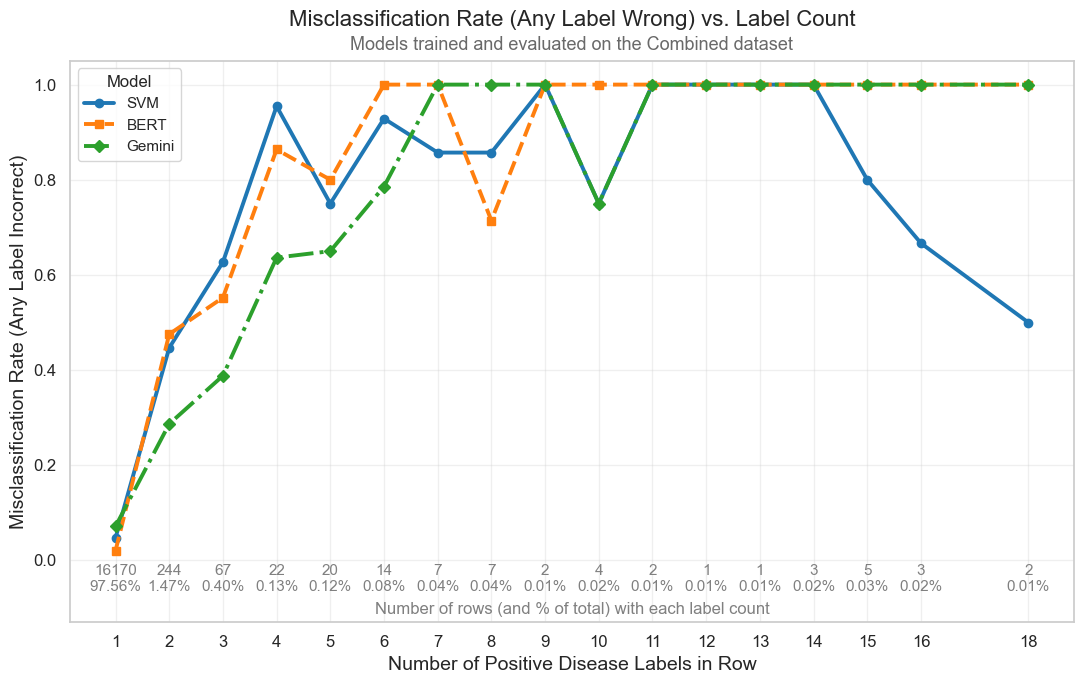

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Label count per row
df_merged_all["label_count"] = df_merged_all[DISEASE_LIST].sum(axis=1)

# 2. Data for plot
plot_data = []
row_count_by_label = df_merged_all["label_count"].value_counts().sort_index()
total_rows = len(df_merged_all)

for model in ["SVM", "BERT", "Gemini"]:
    for label_count, group in df_merged_all.groupby("label_count"):
        total = len(group)
        misclassified = (~group[f"{model}_correct"]).sum()
        rate = misclassified / total if total > 0 else 0
        plot_data.append({
            "Model": model,
            "Label Count": label_count,
            "Misclassification Rate": rate,
            "Row Count": total,
            "Row %": total / total_rows
        })

plot_df = pd.DataFrame(plot_data)

# 3. Plot setup
sns.set(style="whitegrid")
fig, ax = plt.subplots(figsize=(11, 7))  # Slightly larger figure

palette = {"SVM": "#1f77b4", "BERT": "#ff7f0e", "Gemini": "#2ca02c"}
linestyles = {"SVM": "-", "BERT": "--", "Gemini": "-."}
markers = {"SVM": "o", "BERT": "s", "Gemini": "D"}

for model in ["SVM", "BERT", "Gemini"]:
    model_df = plot_df[plot_df["Model"] == model]
    ax.plot(model_df["Label Count"], model_df["Misclassification Rate"],
            label=model,
            color=palette[model],
            linestyle=linestyles[model],
            marker=markers[model],
            linewidth=2.8)

# 4. Annotations: label count + %
label_counts_sorted = row_count_by_label.sort_index()
for x, count in label_counts_sorted.items():
    if count > 0:
        percent = count / total_rows * 100
        ax.annotate(f"{count}\n{percent:.2f}%", 
                    (x, -0.065), 
                    ha="center", 
                    fontsize=11,  # Larger annotation
                    color="gray")

# 5. Axis labels and improved title
ax.set_xlabel("Number of Positive Disease Labels in Row", fontsize=14)
ax.set_ylabel("Misclassification Rate (Any Label Incorrect)", fontsize=14)
ax.set_title("Misclassification Rate (Any Label Wrong) vs. Label Count", fontsize=16, pad=25)

# Subtitle right below title
ax.text(0.5, 1.02, "Models trained and evaluated on the Combined dataset", 
        transform=ax.transAxes, ha='center', fontsize=13, color='dimgray')

# Annotation description under numbers
ax.text(0.5, 0.015, "Number of rows (and % of total) with each label count", 
        transform=ax.transAxes, ha='center', fontsize=12, color="gray")

# Final formatting
ax.set_xticks(sorted(label_counts_sorted.index))
ax.set_ylim(-0.13, 1.05)
ax.tick_params(axis='both', labelsize=12)  # Increase tick font size
ax.legend(title="Model", fontsize=11, title_fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_48536\1242165537.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.98])


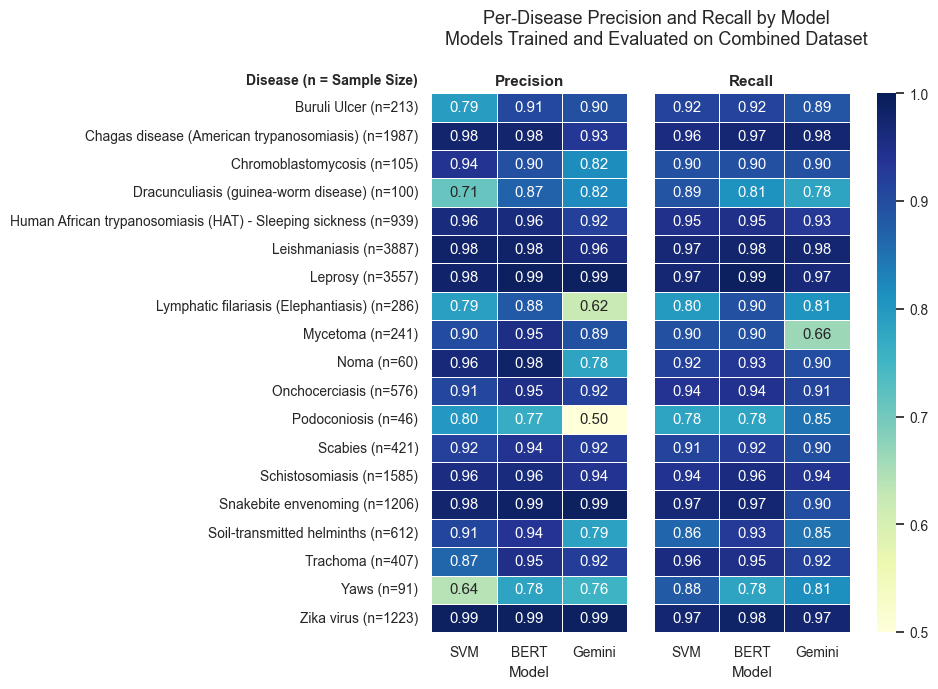

In [119]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up a compact figure
fig, (ax1, ax2, cbar_ax) = plt.subplots(
    1, 3,
    figsize=(6, 7),  # adjust as needed
    gridspec_kw={"width_ratios": [0.5, 0.5, 0.05], "wspace": 0.2},
    constrained_layout=False
)

# Shared heatmap settings
heatmap_kws = dict(
    cmap="YlGnBu",
    annot=True,
    fmt=".2f",
    vmin=0.5,
    vmax=1.0,
    linewidths=0.5,
    linecolor='white'
)

# Precision heatmap
sns.heatmap(precision_pivot, ax=ax1, cbar=False, **heatmap_kws)
ax1.set_title("Precision", fontsize=11,fontweight='bold')
ax1.set_ylabel("")  # Remove axis label
ax1.set_yticklabels(ax1.get_yticklabels(), rotation=0)

# Recall heatmap
sns.heatmap(recall_pivot, ax=ax2, cbar_ax=cbar_ax, **heatmap_kws)
ax2.set_title("Recall", fontsize=11,fontweight='bold')
ax2.set_ylabel("")  # Remove axis label
ax2.set_yticklabels([])

# Manual label text placement — adjust coordinates as needed
ax1.text(-2.85, -0.3, "Disease (n = Sample Size)", fontsize=10, rotation=0,fontweight='bold',)

# Common figure title
plt.suptitle("Per-Disease Precision and Recall by Model\nModels Trained and Evaluated on Combined Dataset",
             fontsize=13, y=1.0)

# Final layout adjustments
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()


In [128]:
def get_disease_misclassifications(disease):
    """
    Returns a DataFrame of all test rows where at least one model misclassified
    the specified disease. Includes FP/FN flags and other disease labels per row.
    """
    # 1. Load base test set
    df_test = pd.read_csv(TEST_FILE)[["row_id", "title", "abstract", "Disease", "mesh_terms"] + DISEASE_LIST]

    # 2. Load and process model predictions
    model_preds = {}
    for model_name, path in MODELS.items():
        df_pred = pd.read_csv(path)
        if model_name == "Gemini":
            df_pred = standardize_gemini_columns(df_pred)
        model_preds[model_name] = df_pred

    # 3. Merge predictions into test set
    df_all = df_test.copy()
    for model_name, df_pred in model_preds.items():
        df_all = df_all.merge(df_pred[["row_id", f"{disease}_pred"]], on="row_id", how="left")

    # 4. Compute misclassification mask per model
    for model in MODELS:
        pred_col = f"{disease}_pred"
        df_all[f"{model}_fp"] = (df_all[disease] == 0) & (df_all[pred_col] == 1)
        df_all[f"{model}_fn"] = (df_all[disease] == 1) & (df_all[pred_col] == 0)
        df_all[f"{model}_wrong"] = df_all[f"{model}_fp"] | df_all[f"{model}_fn"]

    # 5. Identify rows where at least one model misclassified the disease
    wrong_mask = df_all[[f"{m}_wrong" for m in MODELS]].any(axis=1)
    df_errors = df_all[wrong_mask].copy()

    # 6. Add list of other disease labels present
    other_disease_cols = [d for d in DISEASE_LIST if d != disease]
    df_errors["other_diseases"] = df_errors[other_disease_cols].apply(
        lambda row: [d for d in other_disease_cols if row[d] == 1], axis=1
    )

    # 7. Select columns to return
    columns_to_show = [
        "row_id", "title", "abstract", "Disease", disease, "other_diseases"
    ] + [f"{disease}_pred"] + \
        [f"{m}_fp" for m in MODELS] + [f"{m}_fn" for m in MODELS]

    print(f"\n--- Misclassifications for: {disease} ---")
    print(f"Total: {len(df_errors)} rows where at least one model was wrong\n")

    return df_errors[columns_to_show]


In [133]:
df_merged_all.columns

Index(['row_id', 'title', 'abstract', 'Disease', 'mesh_terms', 'Buruli Ulcer',
       'Chagas disease (American trypanosomiasis)', 'Chromoblastomycosis',
       'Dracunculiasis (guinea-worm disease)',
       'Human African trypanosomiasis (HAT) - Sleeping sickness',
       'Leishmaniasis', 'Leprosy', 'Lymphatic filariasis (Elephantiasis)',
       'Mycetoma', 'Noma', 'Onchocerciasis', 'Podoconiosis', 'Scabies',
       'Schistosomiasis', 'Snakebite envenoming', 'Soil-transmitted helminths',
       'Trachoma', 'Yaws', 'Zika virus', 'SVM_correct', 'SVM_error_count',
       'SVM_fp_count', 'SVM_fn_count', 'BERT_correct', 'BERT_error_count',
       'BERT_fp_count', 'BERT_fn_count', 'Gemini_correct',
       'Gemini_error_count', 'Gemini_fp_count', 'Gemini_fn_count',
       'models_wrong_count', 'any_wrong', 'all_correct', 'all_wrong',
       'only_svm_wrong', 'only_bert_wrong', 'only_gemini_wrong'],
      dtype='object')

In [134]:
get_disease_misclassifications("Dracunculiasis (guinea-worm disease)")

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_48536\815210785.py:7: DtypeWarning: Columns (20,22,23,24,25,26,28,34,35,36,37,38,39,40,45,46,53,56,57) have mixed types. Specify dtype option on import or set low_memory=False.
  df_test = pd.read_csv(TEST_FILE)[["row_id", "title", "abstract", "Disease", "mesh_terms"] + DISEASE_LIST]



--- Misclassifications for: Dracunculiasis (guinea-worm disease) ---
Total: 39 rows where at least one model was wrong



,row_id,title,abstract,Disease,Dracunculiasis (guinea-worm disease),other_diseases,Dracunculiasis (guinea-worm disease)_pred,SVM_fp,BERT_fp,Gemini_fp,SVM_fn,BERT_fn,Gemini_fn
98,98,Use of the Dermatology Life Quality Index suit...,<p>Skin neglected tropical diseases (NTDs) aff...,"['Buruli Ulcer', 'Leishmaniasis', 'Leprosy (Ha...",0,"[Buruli Ulcer, Leishmaniasis, Leprosy, Lymphat...",1,True,True,True,False,False,False
320,320,Infectious diseases in the 21st century.,<p>Infecto-contagious diseases in the twenty-f...,['Leprosy (Hansen disease)'],0,[Leprosy],1,True,True,True,False,False,False
579,579,"Forgotten people, forgotten diseases : The neg...",Some of the worst tropical diseases in the wor...,"['Buruli Ulcer', 'Leprosy (Hansen disease)']",0,"[Buruli Ulcer, Leprosy]",1,True,True,True,False,False,False
712,712,Burden of neglected tropical diseases and acce...,<p><strong>Background: </strong>More than 1.7 ...,"['Dracunculiasis (guinea-worm disease)', 'Leis...",1,"[Leishmaniasis, Lymphatic filariasis (Elephant...",0,False,False,False,True,True,True
854,854,Towards Sustainable Impact: Future Directions ...,<p>Social work profession can work alongside o...,"['Buruli Ulcer', 'Chromoblastomycosis', 'Chaga...",1,"[Buruli Ulcer, Chagas disease (American trypan...",0,False,False,False,True,True,True
896,896,One Health Joint Plan of Action (2022–2026): W...,<p>The Quadripartite Organizations – the Food ...,"['Buruli Ulcer', 'Chagas disease (American try...",1,"[Buruli Ulcer, Chagas disease (American trypan...",0,False,False,False,True,True,True
1019,1019,[Foot health in the tropics].,<p>The foot is particularly exposed to injury ...,['Leprosy (Hansen disease)'],0,[Leprosy],1,True,True,True,False,False,False
1193,1193,Eastern Mediterranean Region plan 2021–2025 to...,<p>During the implementation of the first negl...,"['Dracunculiasis (guinea-worm disease)', 'Leis...",1,"[Leishmaniasis, Leprosy, Lymphatic filariasis ...",0,False,False,False,True,True,True
1434,1434,Tropical Diseases in Women,<p>The tropical diseases caused by infectious ...,"['Dracunculiasis (guinea-worm disease)', 'Leis...",1,"[Leishmaniasis, Leprosy, Lymphatic filariasis ...",0,False,False,False,True,True,True
1467,1467,Factors related to willingness to participate ...,<p><strong>Background:</strong> Understanding ...,"['Mycetoma', 'Onchocerciasis', 'Podoconiosis',...",0,"[Mycetoma, Onchocerciasis, Podoconiosis, Schis...",1,True,True,True,False,False,False


In [135]:
get_disease_misclassifications("Lymphatic filariasis (Elephantiasis)")

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_48536\815210785.py:7: DtypeWarning: Columns (20,22,23,24,25,26,28,34,35,36,37,38,39,40,45,46,53,56,57) have mixed types. Specify dtype option on import or set low_memory=False.
  df_test = pd.read_csv(TEST_FILE)[["row_id", "title", "abstract", "Disease", "mesh_terms"] + DISEASE_LIST]



--- Misclassifications for: Lymphatic filariasis (Elephantiasis) ---
Total: 195 rows where at least one model was wrong



,row_id,title,abstract,Disease,Lymphatic filariasis (Elephantiasis),other_diseases,Lymphatic filariasis (Elephantiasis)_pred,SVM_fp,BERT_fp,Gemini_fp,SVM_fn,BERT_fn,Gemini_fn
183,183,Integrated services for neglected tropical dis...,<p><strong>Background:&nbsp;</strong>The World...,"['Leprosy (Hansen disease)', 'Lymphatic filari...",1,[Leprosy],0,False,False,False,True,True,True
195,195,Magnitude of neglected tropical diseases in In...,<p>The world will enter the postmillennium dev...,"['Buruli Ulcer', 'Leprosy (Hansen disease)', '...",1,"[Buruli Ulcer, Leprosy, Schistosomiasis, Soil-...",0,False,False,False,True,True,True
218,218,Determinants of podoconiosis among residents o...,<p><strong>Background:</strong> Podoconiosis (...,['Podoconiosis'],0,[Podoconiosis],1,True,True,True,False,False,False
277,277,Stronger together: evidence for collaborative ...,<p>This editorial has been written by programm...,"['Lymphatic filariasis (Elephantiasis)', 'Onch...",1,"[Onchocerciasis, Schistosomiasis, Soil-transmi...",0,False,False,False,True,True,True
290,290,Lifecycle management of insecticides used for ...,<jats:title>Abstract</jats:title>\r\n <...,"['Leishmaniasis', 'Lymphatic filariasis (Eleph...",1,"[Leishmaniasis, Onchocerciasis]",0,False,False,False,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
16194,16194,Boron-Pleuromutilins as Anti- Wolbachia Agents...,A series of pleuromutilins modified by introdu...,NaN,0,[Onchocerciasis],1,True,True,True,False,False,False
16343,16343,Nitrocellulose dot-ELISA for serodiagnosis of ...,The diagnostic value of the nitrocellulose (NC...,NaN,0,[Schistosomiasis],1,True,True,True,False,False,False
16422,16422,Discovery and clinical importance of the filar...,Macrofilariae have been recognized for many mi...,NaN,0,[Dracunculiasis (guinea-worm disease)],1,True,True,True,False,False,False
16446,16446,[Nematode larva migrans. On two cases of filar...,"With rapid air travel, so-called parasitic inf...",NaN,0,[Onchocerciasis],1,True,True,True,False,False,False


In [ ]:
get_disease_misclassifications("Yaws")


C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_48536\815210785.py:7: DtypeWarning: Columns (20,22,23,24,25,26,28,34,35,36,37,38,39,40,45,46,53,56,57) have mixed types. Specify dtype option on import or set low_memory=False.
  df_test = pd.read_csv(TEST_FILE)[["row_id", "title", "abstract", "Disease", "mesh_terms"] + DISEASE_LIST]



--- Misclassifications for: Yaws ---
Total: 41 rows where at least one model was wrong



,row_id,title,abstract,Disease,Yaws,other_diseases,Yaws_pred,SVM_fp,BERT_fp,Gemini_fp,SVM_fn,BERT_fn,Gemini_fn
98,98,Use of the Dermatology Life Quality Index suit...,<p>Skin neglected tropical diseases (NTDs) aff...,"['Buruli Ulcer', 'Leishmaniasis', 'Leprosy (Ha...",0,"[Buruli Ulcer, Leishmaniasis, Leprosy, Lymphat...",1,True,True,True,False,False,False
195,195,Magnitude of neglected tropical diseases in In...,<p>The world will enter the postmillennium dev...,"['Buruli Ulcer', 'Leprosy (Hansen disease)', '...",1,"[Buruli Ulcer, Leprosy, Lymphatic filariasis (...",0,False,False,False,True,True,True
298,298,Narrative Review on Endemic Communicable Disea...,<p>African nations have experienced various en...,"['Leishmaniasis', 'Leprosy (Hansen disease)', ...",0,"[Leishmaniasis, Leprosy, Schistosomiasis, Soil...",1,True,True,True,False,False,False
325,325,A mixed methods evaluation of an integrated tr...,<p>Background: The overall burden of neglected...,"['Buruli Ulcer', 'Leprosy (Hansen disease)', '...",0,"[Buruli Ulcer, Leprosy, Lymphatic filariasis (...",1,True,True,True,False,False,False
330,330,Evaluating the World Health Organization’s Ski...,<p><strong>Background:&nbsp;</strong>Neglected...,"['Buruli Ulcer', 'Leishmaniasis', 'Leprosy (Ha...",1,"[Buruli Ulcer, Leishmaniasis, Leprosy, Lymphat...",0,False,False,False,True,True,True
669,669,Exploring the value of community engagement ac...,<p><strong>Background:</strong> Skin Neglected...,"['Buruli Ulcer', 'Leishmaniasis', 'Leprosy (Ha...",1,"[Buruli Ulcer, Leishmaniasis, Leprosy, Lymphat...",0,False,False,False,True,True,True
824,824,Oral Complications related to tropical infecti...,<p><strong>Backgrounds:</strong> The non-indig...,"['Leishmaniasis', 'Leprosy (Hansen disease)', ...",1,"[Leishmaniasis, Leprosy]",0,False,False,False,True,True,True
854,854,Towards Sustainable Impact: Future Directions ...,<p>Social work profession can work alongside o...,"['Buruli Ulcer', 'Chromoblastomycosis', 'Chaga...",1,"[Buruli Ulcer, Chagas disease (American trypan...",0,False,False,False,True,True,True
896,896,One Health Joint Plan of Action (2022–2026): W...,<p>The Quadripartite Organizations – the Food ...,"['Buruli Ulcer', 'Chagas disease (American try...",1,"[Buruli Ulcer, Chagas disease (American trypan...",0,False,False,False,True,True,True
917,917,Milestones; Disease Elimination Success Stories,Since the eradication of smallpox worldwide in...,"['Dracunculiasis (guinea-worm disease)', 'Lymp...",0,"[Dracunculiasis (guinea-worm disease), Lymphat...",1,True,True,True,False,False,False


In [136]:
get_disease_misclassifications("Podoconiosis")

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_48536\815210785.py:7: DtypeWarning: Columns (20,22,23,24,25,26,28,34,35,36,37,38,39,40,45,46,53,56,57) have mixed types. Specify dtype option on import or set low_memory=False.
  df_test = pd.read_csv(TEST_FILE)[["row_id", "title", "abstract", "Disease", "mesh_terms"] + DISEASE_LIST]



--- Misclassifications for: Podoconiosis ---
Total: 46 rows where at least one model was wrong



,row_id,title,abstract,Disease,Podoconiosis,other_diseases,Podoconiosis_pred,SVM_fp,BERT_fp,Gemini_fp,SVM_fn,BERT_fn,Gemini_fn
325,325,A mixed methods evaluation of an integrated tr...,<p>Background: The overall burden of neglected...,"['Buruli Ulcer', 'Leprosy (Hansen disease)', '...",0,"[Buruli Ulcer, Leprosy, Lymphatic filariasis (...",1,True,True,True,False,False,False
596,596,A global call for action to tackle skin-relate...,"<p>On 8 June 2022, the World Health Organizati...","['Buruli Ulcer', 'Leishmaniasis', 'Leprosy (Ha...",0,"[Buruli Ulcer, Leishmaniasis, Leprosy, Lymphat...",1,True,True,True,False,False,False
680,680,Social stigma towards neglected tropical disea...,<p><strong>Background</strong> People affected...,['Leprosy (Hansen disease)'],0,[Leprosy],1,True,True,True,False,False,False
712,712,Burden of neglected tropical diseases and acce...,<p><strong>Background: </strong>More than 1.7 ...,"['Dracunculiasis (guinea-worm disease)', 'Leis...",1,"[Dracunculiasis (guinea-worm disease), Leishma...",0,False,False,False,True,True,True
1010,1010,Community based integrated wound care: Results...,<p>Appropriate treatment of chronic wounds is ...,"['Buruli Ulcer', 'Leishmaniasis', 'Leprosy (Ha...",0,"[Buruli Ulcer, Leishmaniasis, Leprosy, Lymphat...",1,True,True,True,False,False,False
1019,1019,[Foot health in the tropics].,<p>The foot is particularly exposed to injury ...,['Leprosy (Hansen disease)'],0,[Leprosy],1,True,True,True,False,False,False
1221,1221,Potential Dermatological Effects of Climate Ch...,<p>Climate change represents a major existenti...,"['Buruli Ulcer', 'Leishmaniasis', 'Podoconiosi...",1,"[Buruli Ulcer, Leishmaniasis, Scabies, Schisto...",0,False,False,False,True,True,True
1222,1222,Social Work with Populations Vulnerable to Neg...,<p>This book discusses the need to establish s...,"['Buruli Ulcer', 'Chromoblastomycosis', 'Chaga...",0,"[Buruli Ulcer, Chagas disease (American trypan...",1,True,True,True,False,False,False
2106,2106,Towards Building Internet-of-Things-Inclusive ...,<p>This work presents a comprehensive review o...,"['Buruli Ulcer', 'Chagas disease (American try...",0,"[Buruli Ulcer, Chagas disease (American trypan...",1,True,True,True,False,False,False
2112,2112,A call to action for mycetoma.,<div>\r\n<h3>Purpose of Review</h3>\r\n\r\n<p>...,['Mycetoma'],0,[Mycetoma],1,True,True,True,False,False,False
